In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
G_raw = ox.graph_from_place(
    "Manhattan, New York, USA",
    network_type="drive",
    simplify=True,
)
fig, ax = plt.subplots(figsize=(8, 8))
plt.close(fig)
# 2. Plot it to verify (Manhattan is dense, so this might take a moment)
fig, ax = ox.plot_graph(
    G_raw,
    node_size=0,
    edge_linewidth=0.5,
    ax=ax,
    close=True,
    save=True,
    filepath=IMG_DIR / MANHATTAN_BASIC,
    dpi=1_000,
)

print(f"Nodes: {G_raw.number_of_nodes()}")
print(f"Edges: {G_raw.number_of_edges()}")

Nodes: 4619
Edges: 9901


## Basic Save / Load

In [4]:
MAP_DIR

PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps')

In [ ]:
ox.save_graphml(G_raw, filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

In [13]:
G_out = ox.load_graphml(filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

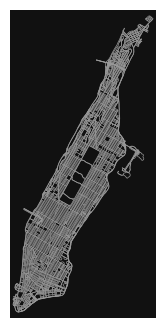

In [28]:
fig, ax = ox.plot_graph(G_out, node_size=0, edge_linewidth=0.5, figsize=(4, 4))

## Preprocess Graph

In [15]:
G = preprocess_graph(G_raw)

In [26]:
# inspect_graph(G)

In [27]:
# plot_maxspeed(G)

In [ ]:
ox.save_graphml(G, filepath=MAP_DIR / MANHATTAN_PROCESSED_GRAPH)

## Sparsify Graph

In [20]:
G = sparsify_graph(G)

Removing 4727 non-major edges...
Graph after edge removal: G_sparsified.number_of_nodes()=3517, G_sparsified.number_of_edges()=5173
Cleaning all edge attributes before simplification...
Removing 110 isolated or pass-through nodes...
Cleaning all edge attributes before simplification...
Final simplified graph: G_ret.number_of_nodes()=794, G_ret.number_of_edges()=1645


In [24]:
sparse_graph_name = MANHATTAN_SPARSE_GRAPH.format(G.number_of_nodes())
sparse_graph_name

'manhattan-sparse-794-edges.graphml'

In [25]:
ox.save_graphml(G, filepath=MAP_DIR / sparse_graph_name)